★実行環境の選択

In [ ]:
# VSCodeの場合
# edi_flg = 1
# Googlre Colabの場合
edi_flg = 0

In [ ]:
import os

repo_path = "/content/My_Python_project"

if edi_flg == 0:
  # GoogleColabにGitHubリポジトリがクローンされていなければ
  # GoogleColabにGitHubリポジトリをクローンする用
  if not os.path.exists(repo_path):
    %cd /content/My_Python_project
    !git clone https://github.com/keiseki-eng/My_Python_project.git
    !git pull origin main



In [ ]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [ ]:
if edi_flg == 0:
    !pip install japanize-matplotlib

import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import japanize_matplotlib #日本語表示対応
from sklearn.model_selection import KFold


# Notebook から src ディレクトリを追加
# sys.path.append(os.path.join(os.getcwd(), "src"))
sys.path.append("/home/keiseki/My_Python_project/src")

In [ ]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [ ]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../config/config.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/含水率判定/config.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)

In [ ]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']

In [ ]:
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

## 02.データ読み込み

In [ ]:
# VSCode用
if edi_flg==1:
# ドライブ内のファイルパスを指定
    train_path = '../20.Data/含水率判定/preprocessed_train.pkl'
    df_train = pd.read_pickle(train_path)

# GoogleColab用
elif edi_flg==0:
    # GoogleDriveをマウントしてファイル読み込み準備
    from google.colab import drive
    drive.mount('/content/drive')
    # ドライブ内のファイルパスを指定
    train_path = '/content/My_Python_project/20.Data/含水率判定/preprocessed_train.pkl'
    df_train = pd.read_pickle(train_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# testデータの読み込み
# VSCode用
if edi_flg==1:
    test_path = '../20.Data/含水率判定/preprocessed_test.pkl'
    df_test = pd.read_pickle(test_path)

# GoogleColab用
elif edi_flg==0:
    # ドライブ内のファイルパスを指定
    test_path = '/content/My_Python_project/20.Data/含水率判定/preprocessed_test.pkl'
    df_test = pd.read_pickle(test_path)

In [ ]:
# from sklearn.model_selection import KFold
# import numpy as np

# def target_encode_oof(
#     df,
#     col,
#     target,
#     n_splits=5,
#     smoothing=10,
#     random_state=42
# ):
#     df = df.copy()

#     # ★ここが最重要
#     df[target] = df[target].astype(float)
#     global_mean = df[target].mean()

#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
#     te_col = np.zeros(len(df))

#     for train_idx, valid_idx in kf.split(df):
#         train_fold = df.iloc[train_idx]
#         valid_fold = df.iloc[valid_idx]

#         stats = (
#             train_fold
#             .groupby(col, observed=True)[target]
#             .agg(["mean", "count"])
#         )

#         stats["smooth"] = (
#             stats["count"] * stats["mean"]
#             + smoothing * global_mean
#         ) / (stats["count"] + smoothing)

#         te_col[valid_idx] = (
#             valid_fold[col]
#             .map(stats["smooth"])
#             .astype(float)          # ← ★ここでカテゴリ解除
#             .fillna(global_mean)
#             .values
#           )


#     df[f"{col}_TE"] = te_col
#     return df, global_mean


In [ ]:
# stats_full = df_train.groupby("addr1+2")["含水率"].agg(["mean", "count"])

# stats_full["smooth"] = (
#     stats_full["count"] * stats_full["mean"]
#     + 20 * addr1_2_global_mean
# ) / (stats_full["count"] + 20)

# # df_test["addr1+2_TE"] = df_test["addr1+2"].map(stats_full["smooth"])
# # df_test["addr1+2_TE"].fillna(addr1_2_global_mean, inplace=True)
# df_test["addr1+2_TE"] = (
#     df_test["addr1+2"]
#     .map(stats_full["smooth"])
#     .astype(float)                 # ← ★最重要
#     .fillna(addr1_2_global_mean)   # ← inplace を使わない
# )



In [ ]:
# # 実際の売買価格で定義し直す
# def make_price_band_by_quantile(price, n_bins=5):
#     return pd.qcut(price, q=n_bins, labels=False)

# df_train["price_band"] = make_price_band_by_quantile(
#     df_train["含水率"],
#     n_bins=5
# )

# def make_sample_weight(price_band):
#     weight_map = {
#         0: 9.0,   # 最低価格帯
#         1: 1.4,
#         2: 1.2,
#         3: 1.2,
#         4: 1.0    # 高価格帯
#     }
#     return price_band.map(weight_map).astype(float)
# df_train["sample_weight"] = make_sample_weight(
#     df_train["price_band"]
# )

# ★trainとtestで樹種が全然違う気がする！　学習時点から樹種を見ないのも一手か・・・？

## interaction特徴量を追加

In [ ]:
# df_train["unit_area_x_walk_distance1"] = df_train["unit_area"] * df_train["walk_distance1"]
# df_train["unit_area_x_addr_te"]    = df_train["unit_area"] * df_train["addr1+2_TE"]
# df_test["unit_area_x_walk_distance1"] = df_test["unit_area"] * df_test["walk_distance1"]
# df_test["unit_area_x_addr_te"]    = df_train["unit_area"] * df_test["addr1+2_TE"]

In [ ]:
# feature_list = feature_list + ["pseudo_price_band"]
# feature_list = feature_list + ["addr1+2_TE"]
# feature_list = feature_list + ["unit_area_x_walk_distance1"]
# feature_list = feature_list + ["unit_area_x_addr_te"]
# categorical_cols = categorical_cols + ["pseudo_price_band"]


## 05.train/valid 分割　＆　target加工

＿★サンプルウェイトを価格帯別に調整可能とする

In [ ]:
# X_all, X_train, X_validの再構築
X_all = df_train.drop(columns=["含水率"])
y_all = df_train["含水率"]

# # log変換前の元価格を保存（後段の重み付け用）
# y_price_raw = df_train.loc[X_all.index, "含水率"]

# unit_areaも対数変換
# X_all["unit_area"] = np.log1p(X_all["unit_area"])

# df_train["unit_area"] = np.log1p(df_train["unit_area"])



# 目的変数が右に裾野が広いので対数変換
# y_all = np.log1p(y_all)


# X_train, X_valid, y_train, y_valid, w_train, w_valid = train_test_split(X_all, y_all, df_train["sample_weight"], test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

## 06.樹種カラム他をカテゴリデータ化

In [ ]:
cat_cols = ["species number", "樹種"]

for c in cat_cols:
    X_train[c] = X_train[c].astype("category")

    X_valid[c] = pd.Categorical(
        X_valid[c],
        categories=X_train[c].cat.categories
    )

    df_test[c] = pd.Categorical(
        df_test[c],
        categories=X_train[c].cat.categories
    )

## 07.モデル学習

In [ ]:
# カスタム評価関数（eval_metric形式）
def mape_eval(preds, train_data):
    y_true = (train_data.get_label())
    y_pred = (preds)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100
    return 'mape', mape, False


In [ ]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    # weight=w_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)

In [ ]:
# モデルの学習
model = lgb.train(params,
                  lgb_train,
                  valid_sets=[lgb_train, lgb_test],
                  feval=mape_eval,  # ← カスタム評価関数を指定
                  callbacks=[lgb.early_stopping(stopping_rounds=1000, verbose=False)
                  ]) #early_stoppingあり

/tmp/ipykernel_275/3693020484.py:3: RuntimeWarning: overflow encountered in expm1
  y_true = np.expm1(train_data.get_label())
/tmp/ipykernel_275/3693020484.py:5: RuntimeWarning: invalid value encountered in divide
  mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

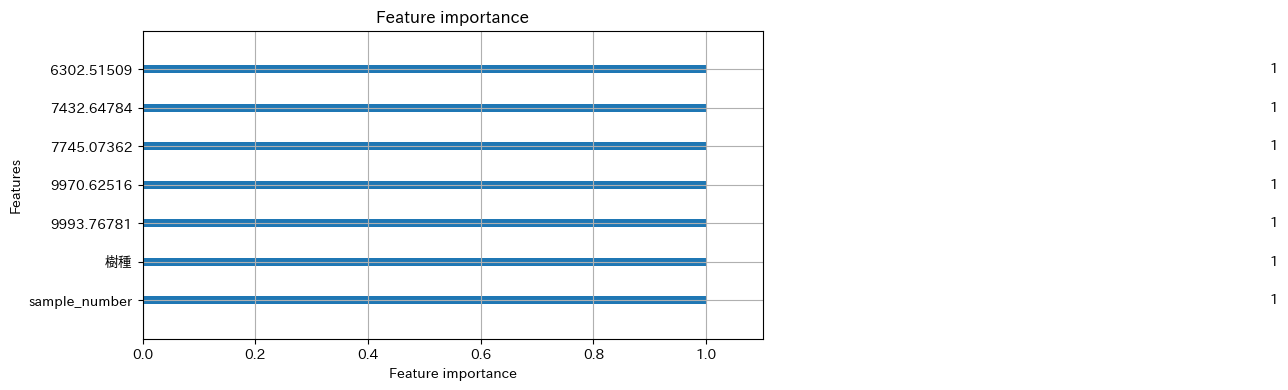

In [ ]:
# テストデータで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 対数変換を戻す
# y_pred = np.expm1(y_pred)
# y_valid = np.expm1(y_valid)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [ ]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [ ]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [ ]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


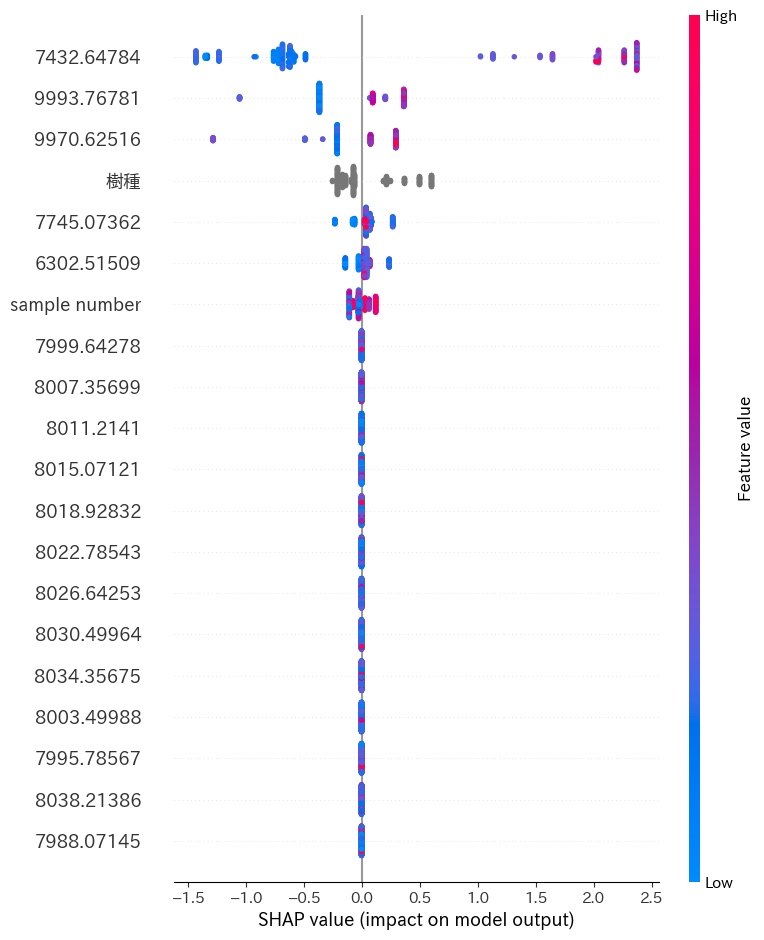

In [ ]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

# ★テストデータと学習データで樹種が全然違うから、ワンホットエンコーディングの結果のカラムが違うんだ！　⇨　とりあえずベースラインではconfigでワンホットエンコーディングを消しとこう・・・

In [ ]:
# df_trainとdf_testのカラムの差分を確認したい
train_cols = set(X_train.columns)
test_cols  = set(df_test.columns)

# trainにあってtestにない
print("Only in train:")
print(train_cols - test_cols)

# testにあってtrainにない
print("\nOnly in test:")
print(test_cols - train_cols)

Only in train:
set()

Only in test:
set()


In [ ]:
# 特徴量の選定
# df_test_p = df_test[feature_list].copy()

# 予測
y_scores_submit = model.predict(df_test)

# print(y_scores_submit)

[32.49728985 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985
 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985
 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985
 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985 32.49728985
 32.49728985 32.49728985 30.03715096 30.03715096 30.03715096 30.03715096
 29.05875006 29.05875006 29.05875006 29.05875006 29.05875006 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188 28.04701188
 28.04701188 28.04701188 28.04701188 28.04701188 28

In [ ]:
#提出用csvの作成
df_scores_submit = pd.DataFrame(y_scores_submit)
df_submit = pd.concat([df_test["sample number"], df_scores_submit], axis=1)

df_submit.to_csv("submit.csv", index=False, header=False)



## 誤差要因分析
## ★とんでもないハズレ値が１件いてる！？

<Axes: ylabel='Frequency'>

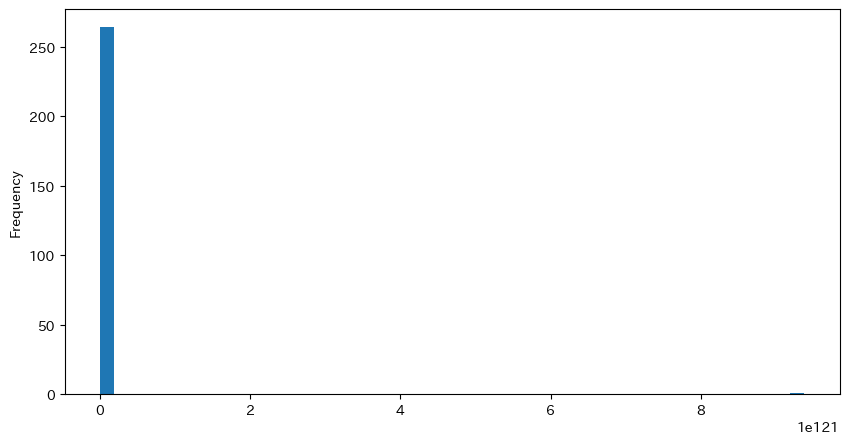

In [ ]:
# valid予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
# 対数変換を戻す
# y_pred_valid = np.expm1(y_pred_valid)

df_eval = X_valid.copy()
df_eval["y_true"] = y_valid
df_eval["y_pred"] = y_pred_valid

# APE計算（0割防止）
df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# 上位ワースト確認
# df_eval.sort_values("ape", ascending=False).head(20)
df_eval["スコア差分"] = df_eval["y_true"] - df_eval["y_pred"]
df_eval["スコア差分"].plot.hist(bins=50, figsize=(10,5))

In [ ]:
def compare_distribution(col):
    return pd.DataFrame({
        "train": df_train[col].describe(),
        "valid": X_valid[col].describe()
    })

# compare_distribution("money_rimawari_now")


In [ ]:
# APEが大きい上位10%
threshold = df_eval["ape"].quantile(0.9)
bad_samples = df_eval[df_eval["ape"] >= threshold]

# SHAP値抽出
shap_values_valid = explainer.shap_values(X_valid)
shap_df = pd.DataFrame(
    shap_values_valid,
    columns=X_valid.columns,
    index=X_valid.index
)


# 悪いサンプルのSHAP平均
shap_df.loc[bad_samples.index].abs().mean().sort_values(ascending=False).head(10)


,0
7432.64784,0.872087
9993.76781,0.303992
9970.62516,0.180165
樹種,0.171262
7745.07362,0.144126
sample number,0.085131
6302.51509,0.032154
5986.2322,0.000000
5982.37509,0.000000
5990.08931,0.000000


In [ ]:
# shap.force_plot(base_value=explainer.expected_value, shap_values=shap_values, features=X_train)

In [ ]:
def calc_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-7))) * 100


# valid 予測
y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)


# MAPE 出力
valid_mape = calc_mape(y_valid, y_pred_valid)
print(f"VALID MAPE: {valid_mape:.4f}%")


VALID MAPE: 101.8561%


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# df_eval = X_valid.copy()
# df_eval["unit_area"] = np.expm1(df_eval["unit_area"])
# df_eval["y_true"] = y_valid
# df_eval["y_pred"] = y_pred_valid
# df_eval["ape"] = np.abs(df_eval["y_true"] - df_eval["y_pred"]) / np.maximum(df_eval["y_true"], 1e-7)

# # 上位10%の誤差サンプル抽出
# threshold = df_eval["ape"].quantile(0.9)
# bad_samples = df_eval[df_eval["ape"] >= threshold]

# # 調査対象の特徴量リスト
# check_features = [
#     "unit_area",
#     "post1",
#     "floor_plan_code",
#     "walk_distance1",
#     "walk_distance2",
# ]

# # タグ系カラムを抽出（feature_list に基づく）
# tag_features = [col for col in feature_list if col.startswith("tag_")]
# check_features.extend(tag_features)

# # 1. 数値特徴量の誤差 vs 値域の関係
# num_features = ["unit_area", "walk_distance1", "walk_distance2"]
# for col in num_features:
#     plt.figure(figsize=(8,4))
#     sns.scatterplot(data=df_eval, x=col, y="ape", alpha=0.3)
#     sns.scatterplot(data=bad_samples, x=col, y="ape", color="red", alpha=0.5)
#     plt.title(f"{col} と予測誤差(APE)の関係")
#     plt.ylabel("APE")
#     plt.xlabel(col)
#     plt.show()

# # 2. カテゴリ特徴量の誤差分布（箱ひげ図）
# cat_features = ["post1", "floor_plan_code"]
# for col in cat_features:
#     plt.figure(figsize=(10,4))
#     sns.boxplot(x=col, y="ape", data=df_eval)
#     plt.title(f"{col} ごとの予測誤差(APE)分布")
#     plt.xticks(rotation=45)
#     plt.show()

# # 3. タグ系特徴量の影響（悪いサンプルと全体比較）
# for col in tag_features:
#     if col not in df_eval.columns:
#         continue
#     mean_all = df_eval[col].mean()
#     mean_bad = bad_samples[col].mean()
#     print(f"{col}: 全体平均={mean_all:.3f}, 誤差上位10%平均={mean_bad:.3f}")


KeyError: 'unit_area'